In [70]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = "16"

import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
from matplotlib.patches import Arc
import matplotlib.patheffects as pe
import pickle
import seaborn as sns
import sklearn
import torch
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
import statsmodels

import sys
sys.path.append('2D_gastruloids_v5')
import fns_plotting_scripts as fns_plot
import fns_NN
import IIF_analysis as IIF

import importlib
importlib.reload(IIF);
importlib.reload(fns_plot);

In [4]:
dataDir = 'toy_model'
file_suffix = '.png'

In [5]:
# ============================================
# Colormap for fates
# ============================================

colmap_fates = {'AMLC':[90/255,166/255,71/255,1],'PGCLC':[227/255,143/255,52/255,1],
                 'PSLC':[211/255,62/255,43/255,1], 'meso':[140/255,40/255,93/255,1],
                 'pluri':[75/255,167/255,158/255,1], 'ecto':[49/255,118/255,181/255,1], 
                'endo':[227/255,179/255,61/255,1],'other':[0.8,0.8,0.8,1]}

fate_colors = [colmap_fates['AMLC'], colmap_fates['PGCLC'], colmap_fates['PSLC']]

In [6]:
# ============================================
# Generative model functions
# ============================================

def compute_L(s1, s2):
    return (s1 - s2 + 1)/2
    
def hill_increasing(x, K=0, n=4):
    r = x**n/(K**n + x**n)
    r[x<0] = 0
    return r

def hill_decreasing(x, K=0, n=4):
    return 1 - hill_increasing(x, K, n)

def assign_fate(L):
    fate = np.zeros_like(L, dtype=int)
    fate[L < 0.33] = 0
    fate[(L >= 0.33) & (L <= 0.66)] = 1
    fate[L > 0.66] = 2
    return fate

def sample_gaussian_mixture(means, cov, n_samples, weights=None):
    n_components = len(means)
    if weights is None:
        weights = np.ones(n_components) / n_components
    
    component_idx = np.random.choice(n_components, size=n_samples, p=weights)
    
    samples = np.zeros((n_samples, 2))
    for i in range(n_components):
        mask = component_idx == i
        n_comp = mask.sum()
        if n_comp > 0:
            samples[mask] = np.random.multivariate_normal(means[i], cov, n_comp)
    
    samples = np.clip(samples, 0, 1)
    return samples[:, 0], samples[:, 1]

def covMatrix(ev1,ev2,theta):
    
    R = np.array([ # Rotation matrix
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta), np.cos(theta)]
    ])
    # Diagonal covariance (before rotation)
    cov_diag = np.diag([ev1,ev2])  # Major variance = 5, minor = 1
    cov_matrix = R @ cov_diag @ R.T # Rotate: C = R * Λ * R^T

    return cov_matrix

In [16]:
# GENERATE TOY DATA

np.random.seed(40)
torch.manual_seed(40)
    
N = 1000   

s1 = {}
s2 = {}

# Generate display data for conditions
# Condition 1: Uniform (Standard) 
s1['cond1'] = np.random.uniform(0, 1, N)
s2['cond1'] = np.random.uniform(0, 1, N)

# Condition 2: 
means_cond2 = [[0.66, 0.33]]
cov_cond2 = covMatrix(ev1=0.1,ev2=0.005,theta = -np.pi / 4)
s1['cond2'], s2['cond2'] = sample_gaussian_mixture(means_cond2, cov_cond2, N)

# Condition 3: transposed cond2
s1['cond3'] = s2['cond2']
s2['cond3'] = s1['cond2']

# Condition 4: 
means_cond4 = [[0.5, 0.5]]
cov_cond4 = covMatrix(ev1=0.1,ev2=0.005,theta=np.pi / 4)
s1['cond4'], s2['cond4'] = sample_gaussian_mixture(means_cond4, cov_cond4, N)

# format this like the real data
#------------------------------------
signal_names = ['s1','s2']
gene_names = ['L','g1','g2']
conditions = ['cond1', 'cond2', 'cond3', 'cond4']
signal_names_simplified = ['signal 1','signal 2']

toydata = {}
for cond in conditions:
    
    L = compute_L(s1[cond],s2[cond])

    # # mutually exclusive expression
    g1 = hill_increasing(L-0.46, K=0.2, n=12) # to have similar slope same K, then shift
    g2 = hill_decreasing(L-0.13, K=0.2, n=12)

    # overlapping expression
    # g1 = hill_increasing(L-0.13, K=0.2, n=6)
    # g2 = hill_decreasing(L-0.43, K=0.2, n=6)

    toydata[cond] = pd.DataFrame(np.column_stack([s1[cond], s2[cond], L, g1, g2]), columns=signal_names + gene_names)

toydata = pd.concat(toydata, names=['condition']).reset_index()
toydata['Colony'] = np.random.choice([1, 2], size=len(toydata))


fate = assign_fate(toydata['L'])

          g1        g2
s1  0.315956  0.346845
s2  0.344248  0.339645
          g1        g2
s1  1.481760  0.928007
s2  1.520275  0.940638
          g1        g2
s1  0.515742  1.449910
s2  0.515003  1.427128
          g1        g2
s1  0.102817  0.100773
s2  0.089592  0.111657


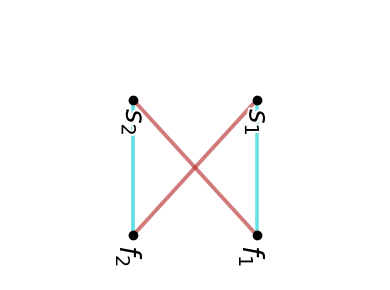

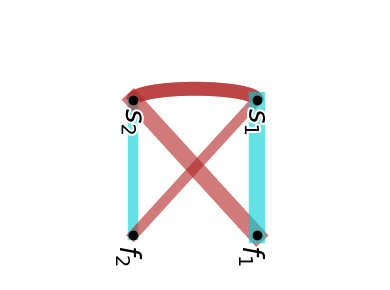

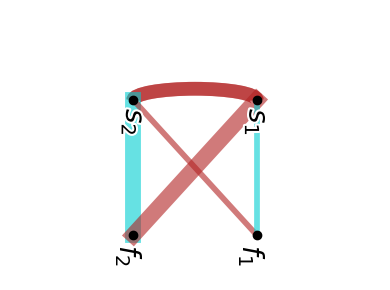

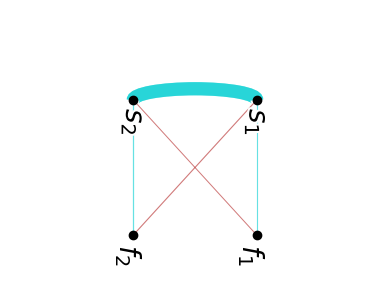

In [71]:
for i,cond in enumerate(conditions):
    MI, MIsigs = IIF.plotMIgraph(dataDir, toydata, cond, signal_names, ['g1','g2'], signames_clean=['$s_1$','$s_2$'], markernames_clean=['$f_1$','$f_2$'], rotate=True, fs=20)
    print(MI)

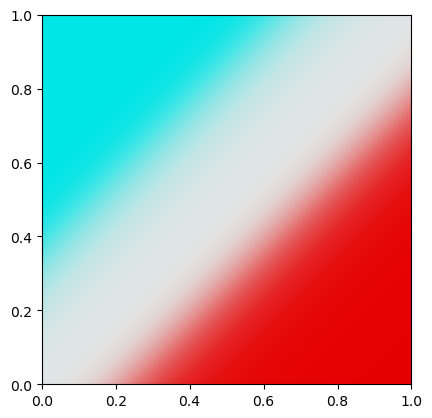

In [18]:
# Create grid
x = np.linspace(0, 1, 200)
y = np.linspace(0, 1, 200)
S1, S2 = np.meshgrid(x, y)

# PLOT MARKER GENES
L = compute_L(S1,S2)
g1 = hill_increasing(L-0.13, K=0.2, n=6)
g2 = hill_decreasing(L-0.43, K=0.2, n=6)
noexpr = (1-g1-g2)


RGB = np.stack([g1*0.9, g2*0.9, g2*0.9],axis=2)
plt.imshow(RGB, aspect='equal', origin='lower', extent=[x.min(), x.max(), y.min(), y.max()])

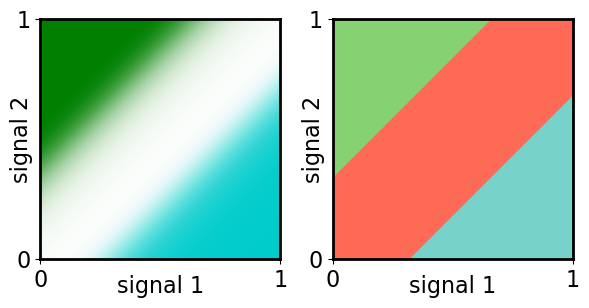

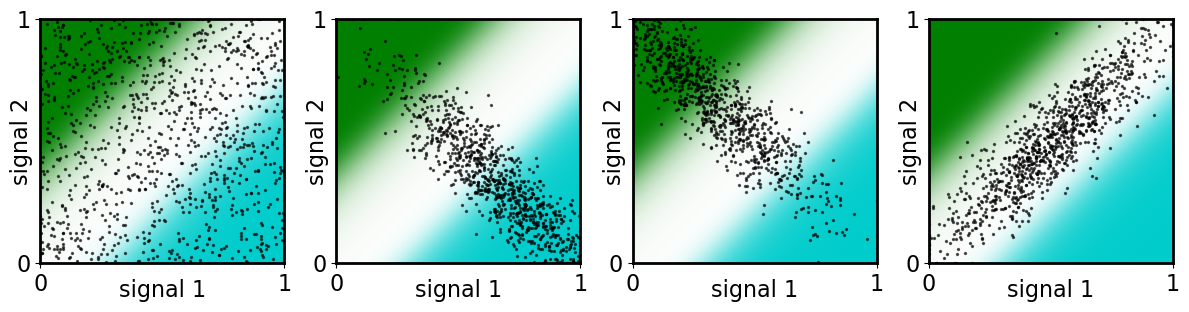

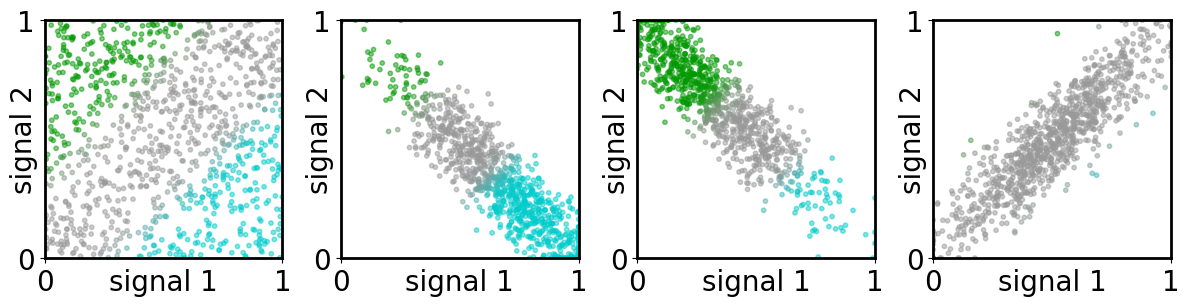

In [19]:
n = 1
m = 2
fig, ax = plt.subplots(n, m, figsize=(3*m, 3*n))
lp = -12
sw = 2
fs = 16

# Create grid
x = np.linspace(0, 1, 200)
y = np.linspace(0, 1, 200)
S1, S2 = np.meshgrid(x, y)

# PLOT MARKER GENES
L = compute_L(S1,S2)

# exclusive
g1 = hill_increasing(L-0.46, K=0.2, n=6)
g2 = hill_decreasing(L-0.13, K=0.2, n=6)


i = 0
noexpr = (1-g1-g2)
RGB = np.stack([noexpr, g2*0.5 +  g1*0.8 + noexpr, g1*0.8  + noexpr],axis=2)
sf = 1
#RGB = np.stack([g2*sf, g1*sf, g1*sf],axis=2)
ax[i].imshow(RGB, aspect='equal', origin='lower', extent=[x.min(), x.max(), y.min(), y.max()])
ax[i].set_xlabel(signal_names_simplified[0],labelpad=lp,fontsize=fs)
ax[i].set_ylabel(signal_names_simplified[1],labelpad=lp,fontsize=fs)
ax[i].set_xticks([0, 1]);
ax[i].set_yticks([0, 1]);
ax[i].tick_params(labelsize=fs)
for spine in ax[i].spines.values():
        spine.set_linewidth(sw)
    
# exclusive
f1 = (g1 > 0.5) 
f2 = (g2 > 0.5) 
f3 = (g1 < 0.5) & (g2 < 0.5)

RGB = np.zeros((*f1.shape, 3))
RGB[f1] = colmap_fates['pluri'][0:3]
RGB[f2] = colmap_fates['AMLC'][0:3]
RGB[f3] = colmap_fates['PSLC'][0:3]
RGB = RGB + 1 - RGB.max().max() # last bit to make it a little brighter

i = 1
ax[i].imshow(RGB, aspect='equal', origin='lower', extent=[x.min(), x.max(), y.min(), y.max()])
ax[i].set_xlabel(signal_names_simplified[0],labelpad=lp,fontsize=fs)
ax[i].set_ylabel(signal_names_simplified[1],labelpad=lp,fontsize=fs)
ax[i].set_xticks([0, 1]);
ax[i].set_yticks([0, 1]);
ax[i].tick_params(labelsize=fs)
for spine in ax[i].spines.values():
        spine.set_linewidth(sw)

plt.tight_layout()
plt.savefig("FigS6/" + 'toymodel_fatemarkers.png')

#===============================
# PLOT FATES WITH CONDITION
#===============================
n = 1
m = len(conditions)
fig, ax = plt.subplots(n, m, figsize=(3*m, 3*n))

for i, cond in enumerate(conditions):
    RGB = np.stack([noexpr, g2*0.5 +  g1*0.8 + noexpr, g1*0.8  + noexpr],axis=2)
    ax[i].imshow(RGB, aspect='equal', origin='lower', extent=[x.min(), x.max(), y.min(), y.max()])
    ax[i].set_xlabel(signal_names_simplified[0],labelpad=lp,fontsize=fs)
    ax[i].set_ylabel(signal_names_simplified[1],labelpad=lp,fontsize=fs)
    ax[i].set_xticks([0, 1]);
    ax[i].set_yticks([0, 1]);
    ax[i].set_ylim([0, 1]);
    ax[i].set_xlim([0, 1]);
    ax[i].tick_params(labelsize=fs)
    for spine in ax[i].spines.values():
        spine.set_linewidth(sw)
    
    mask = (toydata['condition'] == cond)
    ax[i].scatter(toydata['s1'][mask], toydata['s2'][mask], c='k', s=2, alpha=0.6)

plt.tight_layout()
plt.savefig("FigS6/" + 'toymodel_conditional_v_universal.png')


#===============================
# PLOT FATES WITH CONDITION
#===============================
fs = 20
n = 1
m = len(conditions)
fig, ax = plt.subplots(n, m, figsize=(3*m, 3*n))

for i, cond in enumerate(conditions):
    ax[i].set_xlabel(signal_names_simplified[0],labelpad=-20,fontsize=fs)
    ax[i].set_ylabel(signal_names_simplified[1],labelpad=-15,fontsize=fs)
    ax[i].set_xticks([0, 1]);
    ax[i].set_yticks([0, 1]);
    ax[i].set_ylim([0, 1]);
    ax[i].set_xlim([0, 1]);
    ax[i].tick_params(labelsize=fs)
    for spine in ax[i].spines.values():
        spine.set_linewidth(sw)
    
    mask = (toydata['condition'] == cond)
    
    g1 = toydata['g1'][mask]
    g2 = toydata['g2'][mask]
    noexpr = (1-g1-g2)
    sf = 0.6
    sf2 = 0.8
    #colors = np.stack([g2*sf, g1*sf, g1*sf],axis=1)
    colors = np.stack([noexpr*sf, g2*sf +  g1*sf2 + noexpr*sf, g1*sf2  + noexpr*sf],axis=1)

    ax[i].scatter(toydata['s1'][mask], toydata['s2'][mask], c=colors, s=10, alpha=0.5)
    ax[i].set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig("FigS6/" + 'toymodel_conditional_v_universal_v2.png')

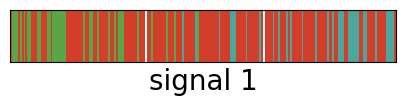

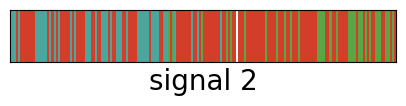

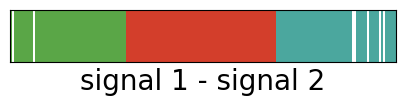

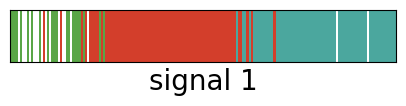

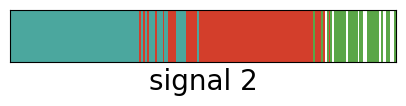

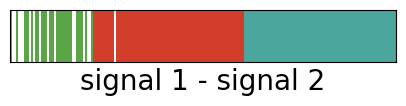

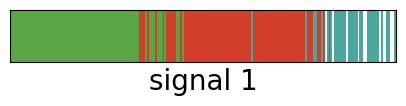

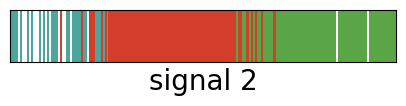

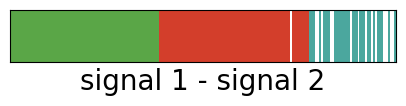

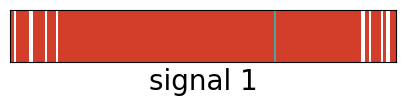

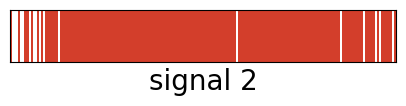

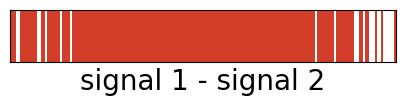

In [20]:
# FATEBAR - using toy model fate colors

n_bins = 200
fs = 20

for cond in conditions:
        
    data_cond = toydata[toydata['condition'] == cond].copy()
    
    # add difference column
    data_cond['s1_minus_s2'] = data_cond['s1'] - data_cond['s2']
    
    toy_signals = ['s1', 's2', 's1_minus_s2']
    toy_labels  = ['signal 1', 'signal 2', 'signal 1 - signal 2']
    
    # Precompute fate colors for all cells in data_cond at once (vectorized)
    s1_vals = data_cond['s1'].to_numpy()
    s2_vals = data_cond['s2'].to_numpy()
    
    L_vals = compute_L(s1_vals.reshape(1, -1), s2_vals.reshape(1, -1))[0, :]
    
    g1_vals = hill_increasing(L_vals - 0.46, K=0.2, n=6)
    g2_vals = hill_decreasing(L_vals - 0.13, K=0.2, n=6)
    
    f1 = g1_vals > 0.5
    f2 = g2_vals > 0.5
    f3 = ~f1 & ~f2
    
    fate_colors_cache = {}
    for i, idx in enumerate(data_cond.index):
        if f1[i]:
            fate_colors_cache[idx] = colmap_fates['pluri'][:3]
        elif f2[i]:
            fate_colors_cache[idx] = colmap_fates['AMLC'][:3]
        else:
            fate_colors_cache[idx] = colmap_fates['PSLC'][:3]
    
    for i, sig in enumerate(toy_signals):
    
        lower_limit = data_cond[sig].quantile(0.01)
        upper_limit = data_cond[sig].quantile(0.99)
    
        data_filtered = data_cond[
            (data_cond[sig] >= lower_limit) & (data_cond[sig] <= upper_limit)
        ].copy()
    
        data_filtered['r_bin'] = pd.cut(data_filtered[sig], bins=n_bins, labels=False)
    
        sampled_cells = []
        for bin_idx in range(n_bins):
            bin_data = data_filtered[data_filtered['r_bin'] == bin_idx]
            if len(bin_data) > 0:
                sample = bin_data.sample(n=1, random_state=0)
                sample_idx = sample.index[0]
                sampled_cells.append({
                    'bin': bin_idx,
                    'color': fate_colors_cache[sample_idx]
                })
    
        sampled_df = pd.DataFrame(sampled_cells)
    
        fig, ax = plt.subplots(figsize=(4, 1))
        for _, row in sampled_df.iterrows():
            ax.barh(0, 1, left=row['bin'], height=1, color=row['color'])
    
        ax.set_xlim(0, n_bins)
        ax.set_ylim(-0.5, 0.5)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel(toy_labels[i], fontsize=fs)
        plt.tight_layout(pad=0.5)
    
        plt.savefig('FigS6/barplot_fate_' + cond + '_' +sig+'.png')
        plt.show()
        plt.close()

In [66]:
# TRAIN THE MODEL

import importlib
importlib.reload(IIF);
importlib.reload(fns_plot);

N_run = 3
hyperparam = {'HIDDEN_DIM':32, 'N_LAYERS':2, 'LATENT_DIM': 2}

data = toydata
signals = signal_names
genes = ['g1','g2']

vib = {}

pred_df = data[signals + genes].copy()    

# predict each colony in B50 based on the other colonies
colony_idx = np.unique(data['Colony'])
for test_colony in colony_idx:
    
    # split data into test and train by colonies
    train_colonies = np.setdiff1d(colony_idx, test_colony)
    data_test = data[data['Colony'].isin([test_colony])]
    data_train = data[data['Colony'].isin(train_colonies)]

    feat_train = data[signals] 
    feat_test = data[signals]
    tar_train = data[gene_names]

    vib[test_colony] = IIF.VIB(feat_train, tar_train, hyperparam)
    if not os.path.exists(dataDir + '/toymodel_'+str(test_colony)+'.pth'):
        print('run VIB')
        _ = vib[test_colony].train(verbose=False)
        #torch.save(vib[test_colony].model, dataDir + '/toymodel_'+str(test_colony)+'.pth')
    else: 
        print('load VIB')
        vib[test_colony].model = torch.load(dataDir + '/toymodel_'+str(test_colony)+'.pth', weights_only=False)
        
    tar_predict = vib[test_colony].predict(feat_test)
    pred_df.loc[tar_predict.index, tar_predict.columns] = tar_predict    

# GET THE LATENT SPACE COORDINATES BASED ON THE MODEL USED FOR THE 1ST COL

model = vib[1].model

toydata['L1'] = np.nan
toydata['L2'] = np.nan

for cond in conditions:

    mask = (toydata['condition'] == cond)
    X = torch.tensor(np.column_stack([toydata['s1'][mask], toydata['s2'][mask]]), dtype=torch.float32)
    X = X.to(device)
    
    # 2D model
    with torch.no_grad():
        _, mu, _ = model(X)
    
    toydata.loc[mask,'L1'] = mu[:, 0].cpu().numpy()
    toydata.loc[mask,'L2'] = mu[:, 1].cpu().numpy()

run VIB
run VIB


C:\Users\bassit\AppData\Local\Temp\ipykernel_41900\4203948898.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(toydata['L1'], toydata['L2'],c=[0.4,0.4,0.4], s=1);


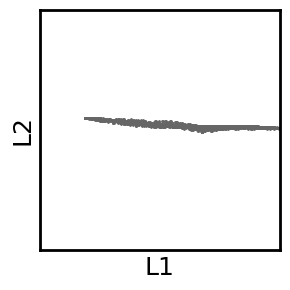

In [67]:
fs=18
sw = 2
n=1
m=1
fig, ax = plt.subplots(n, m, figsize=(3*m, 3*n))

ax.scatter(toydata['L1'], toydata['L2'],c=[0.4,0.4,0.4], s=1);
ax.set_xlabel('L1',fontsize=fs)
ax.set_ylabel('L2',fontsize=fs)
ax.set_xticks([]);
ax.set_yticks([]);
ax.set_ylim([-0.7, 0.7])
ax.set_xlim([-1, 0.4]);
#ax[i].tick_params(labelsize=fs)

for spine in ax.spines.values():
    spine.set_linewidth(sw)

ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.savefig("FigS6/" + 'toymodel_latentspace_'+cond+'.png')

==========L====================
rd: 1
toy_model/251115_VIB_1D_cond1_s1_avg.csv
running: ('s1',)
  Run 0/3
Elapsed time: 4.444538593292236 seconds
  Run 1/3
Elapsed time: 4.34346866607666 seconds
  Run 2/3
Elapsed time: 4.1612653732299805 seconds
toy_model/251115_VIB_1D_cond1_s2_avg.csv
running: ('s2',)
  Run 0/3
Elapsed time: 4.311199188232422 seconds
  Run 1/3
Elapsed time: 4.068363189697266 seconds
  Run 2/3
Elapsed time: 4.107109785079956 seconds
best mean: ('s2',), 0.62(0.00)
selected best: [('s1',), ('s2',)]
rd: 2
toy_model/251115_VIB_2D_cond1_s1_s2_avg.csv
running: ('s1', 's2')
  Run 0/3
Elapsed time: 4.28838849067688 seconds
  Run 1/3
Elapsed time: 4.285762071609497 seconds
  Run 2/3
Elapsed time: 4.235496520996094 seconds
best mean: ('s1', 's2'), 4.28(0.03)
selected best: ('s1', 's2'), 4.28(0.03)
p value 0.0034083883975355757
p value nan
==========g1====================
rd: 1
toy_model/251115_VIB_1D_cond1_s1_avg.csv
toy_model/251115_VIB_1D_cond1_s2_avg.csv
best mean: ('s1',), 0

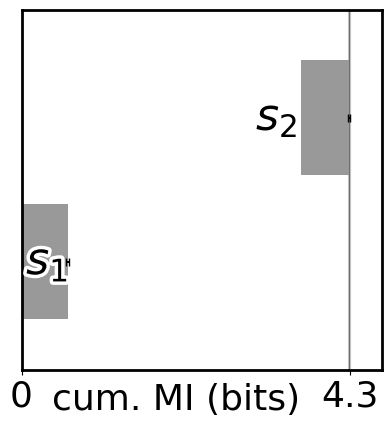

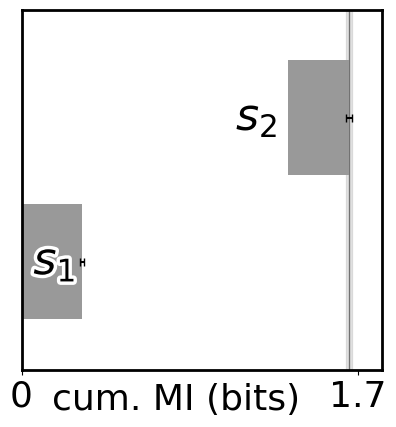

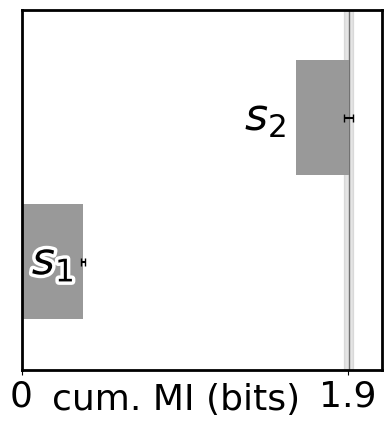

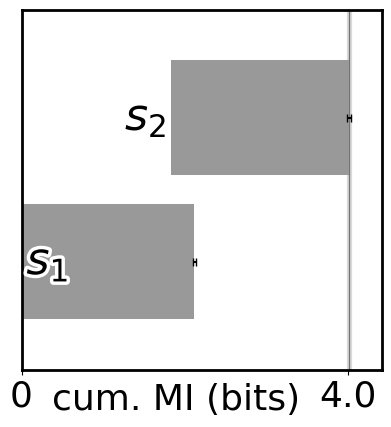

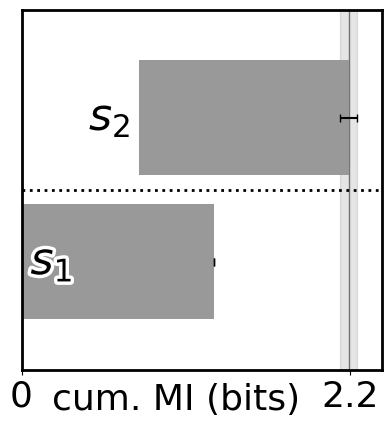

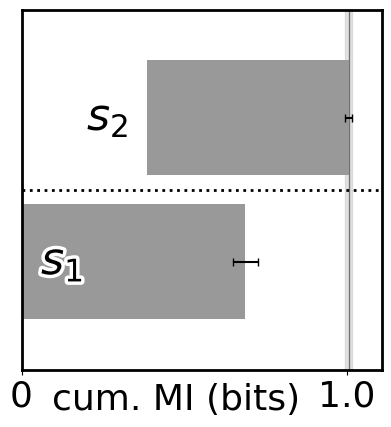

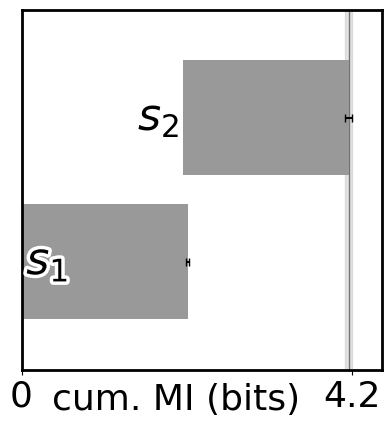

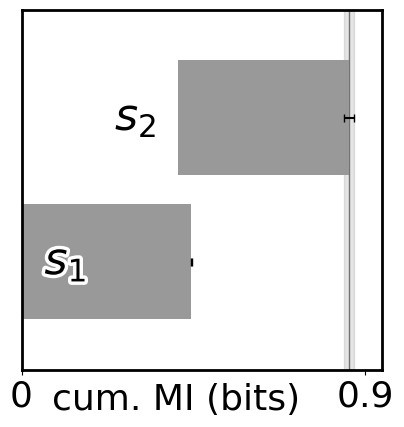

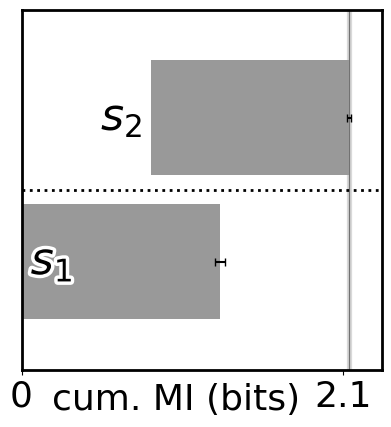

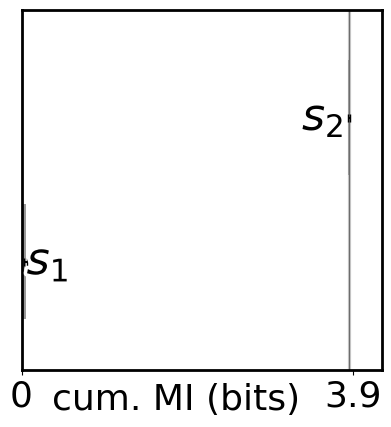

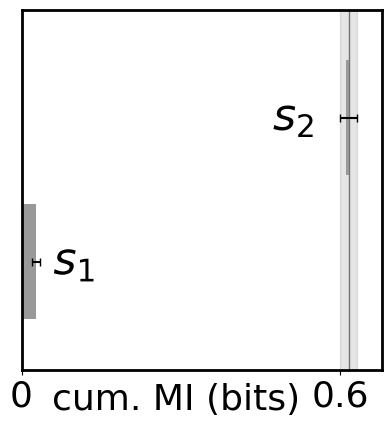

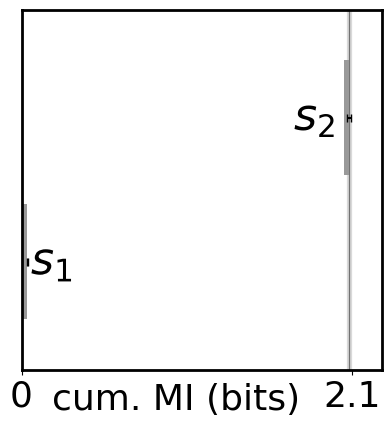

In [40]:
import importlib
importlib.reload(IIF);
importlib.reload(fns_plot);

N_run=3
plotparam = {'fs':26, 'fs2':26, 'fs3':32, 'xlabel':'cum. MI (bits)','labelpad':-22,'x':0.43,'round':1,'marg':0.06}
signames_simple=['$s_1$','$s_2$']
for cond in conditions:
    IIF.plotCumulativeMI(toydata, cond, dataDir, gene_names, signal_names, signames_simple, N_run, hyperparam, plotparam=plotparam, checkoverfit=False, title=False)

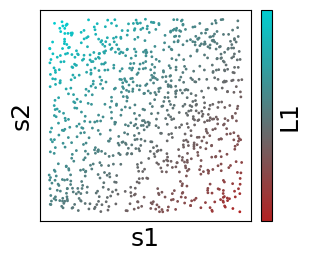

In [41]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as mcolors

colors = ['firebrick', 'darkturquoise']
n_bins = 100
cmap = mcolors.LinearSegmentedColormap.from_list('cyan_red', colors, N=n_bins)

fs=18
n=1
m=1
fig, ax = plt.subplots(n, m, figsize=(3*m, 3*n))

cond = 'cond1'
mask = (toydata['condition'] == cond)
scatter = ax.scatter(toydata['s1'][mask], toydata['s2'][mask], 
                     c=toydata['L1'][mask], s=1, cmap=cmap)
ax.set_xlabel('s1', fontsize=fs)
ax.set_ylabel('s2', fontsize=fs)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal', adjustable='box')

# Create divider for existing axes
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = plt.colorbar(scatter, cax=cax)
cbar.set_label('L1', fontsize=fs)
cbar.set_ticks([])

plt.savefig(dataDir + "/" + 'toymodel_latentspace_v_signals_'+cond+'.png')

In [42]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

degree = 3
alpha = 0.1

# Create grid
x = np.linspace(0, 1, 200)
y = np.linspace(0, 1, 200)
S1, S2 = np.meshgrid(x, y)

# Flatten for fitting
s1_flat = S1.ravel()
s2_flat = S2.ravel()

# Get predictions from your neural network
X = torch.tensor(np.column_stack([s1_flat, s2_flat]), dtype=torch.float32)
X = X.to(device)

# 2D model
with torch.no_grad():
    _, mu, _ = model(X)
    
L1 = mu[:, 0].cpu().numpy()

# Standardize target
scaler_y = StandardScaler()
L1_scaled = scaler_y.fit_transform(L1.reshape(-1, 1)).ravel()

# Create pipeline that standardizes THEN creates polynomials
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=degree)),
    ('ridge', Ridge(alpha=alpha))
])

# Fit the pipeline
X_input = np.column_stack([s1_flat, s2_flat])
pipeline.fit(X_input, L1_scaled)

# Get predictions
predictions = pipeline.predict(X_input)

print(f"R² score: {pipeline.score(X_input, L1_scaled):.6f}")

# Extract coefficients (these will be more reasonable)
poly_features = pipeline.named_steps['poly']
polmodel = pipeline.named_steps['ridge']

feature_names = poly_features.get_feature_names_out(['s1', 's2'])
print("\nCoefficients:")
print(f"Intercept: {polmodel.intercept_:.6f}")
for name, coef in zip(feature_names, polmodel.coef_):
    print(f"{name:15s}: {coef:10.6f}")

R² score: 0.999134

Coefficients:
Intercept: -0.032372
1              :   0.000000
s1             :  -0.689506
s2             :   0.592280
s1^2           :   0.027682
s1 s2          :  -0.024850
s2^2           :   0.004690
s1^3           :   0.003110
s1^2 s2        :   0.038493
s1 s2^2        :  -0.049169
s2^3           :   0.025123


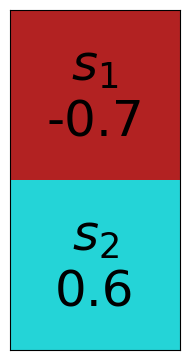

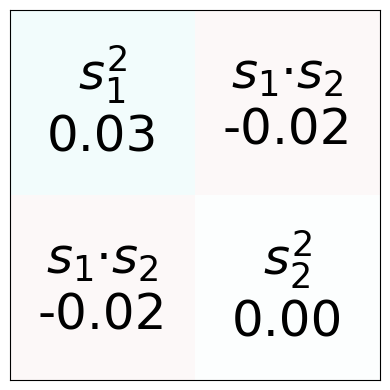

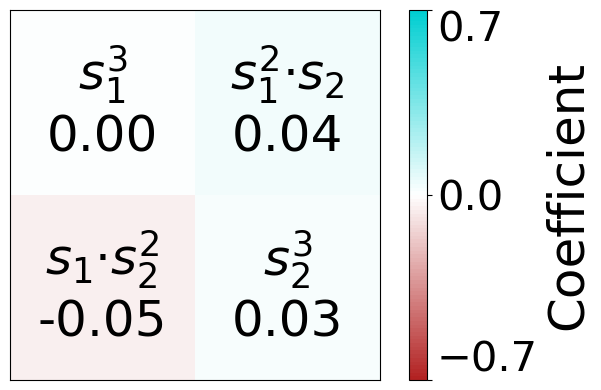

In [43]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors as mcolors

# ===== FONT SIZE PARAMETERS =====
fs_title = 24
fs_axis = 30
fs_val = 36
fs_tick = 30
fs_cb = fs_val

mycolors = ['firebrick', 'white', 'darkturquoise']
n_bins = 100
cmap = mcolors.LinearSegmentedColormap.from_list('cyan_white_red', mycolors, N=n_bins)

# Extract coefficients
feature_names = poly_features.get_feature_names_out(['s1', 's2'])
coef_dict = {name: coef for name, coef in zip(feature_names, polmodel.coef_)}

# ===== CREATE COEFFICIENT MATRICES =====
# Linear coefficients (2x1)
linear_mat = np.array([
    [coef_dict.get('s1', 0)],
    [coef_dict.get('s2', 0)]
])

# Quadratic coefficients (2x2)
quad_mat = np.array([
    [coef_dict.get('s1^2', 0), coef_dict.get('s1 s2', 0)],
    [coef_dict.get('s1 s2', 0), coef_dict.get('s2^2', 0)]
])

# Cubic coefficients (2x2)
cubic_mat = np.array([
    [coef_dict.get('s1^3', 0), coef_dict.get('s1^2 s2', 0)],
    [coef_dict.get('s1 s2^2', 0), coef_dict.get('s2^3', 0)]
])

# Find global scale for consistent coloring
all_vals = [coef_dict.get(k, 0) for k in ['s1', 's2', 's1^2', 's1 s2', 's2^2', 
                                            's1^3', 's1^2 s2', 's1 s2^2', 's2^3']]
vmax = max(abs(min(all_vals)), abs(max(all_vals)))
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

# ===== SAVE INDIVIDUAL PLOTS =====

# 1. Linear only
fig1, ax1 = plt.subplots(figsize=(2, 4))
im_lin = ax1.imshow(linear_mat, cmap=cmap, norm=norm, aspect='equal')
ax1.set_xticks([])
#ax1.set_xticklabels(['coef'], fontsize=fs_tick)
ax1.set_yticks([])
#ax1.set_yticklabels(['s1', 's2'], fontsize=fs_tick)
#ax1.set_title('Linear Coefficients', fontsize=fs_title, fontweight='bold', pad=15)
labels_lin = ['$s_1$', '$s_2$']
for i in range(2):
    ax1.text(0, i, f'{labels_lin[i]}\n{linear_mat[i, 0]:.1f}', ha='center', va='center', fontsize=fs_val)
plt.tight_layout()
plt.savefig(dataDir + '/coefficient_linear.png', dpi=300, bbox_inches='tight')
#plt.close()

# 2. Quadratic only
fig2, ax2 = plt.subplots(figsize=(7, 4))
im_quad = ax2.imshow(quad_mat, cmap=cmap, norm=norm, aspect='equal')
ax2.set_xticks([])
# ax2.set_xticklabels(['s1', 's2'], fontsize=fs_tick)
ax2.set_yticks([])
# ax2.set_yticklabels(['s1', 's2'], fontsize=fs_tick)
# ax2.set_xticklabels([])
# ax2.set_yticklabels([])
#ax2.set_title('Quadratic Coefficients', fontsize=fs_title, fontweight='bold', pad=15)
labels_quad = [['$s_1^2$', '$s_1·s_2$'], ['$s_1·s_2$', '$s_2^2$']]
for i in range(2):
    for j in range(2):
        ax2.text(j, i, f'{labels_quad[i][j]}\n{quad_mat[i,j]:.2f}', 
                ha='center', va='center', fontsize=fs_val)
plt.tight_layout()
plt.savefig(dataDir + '/coefficient_quadratic.png', dpi=300, bbox_inches='tight')
#plt.close()

# 3. Cubic only
fig3, ax3 = plt.subplots(figsize=(7, 4))
vmax = 0.7
im_cubic = ax3.imshow(cubic_mat, cmap=cmap, aspect='equal', vmin=-vmax, vmax=vmax)
ax3.set_xticks([])
#ax3.set_xticklabels(['s1²', 's2²'], fontsize=fs_tick)
ax3.set_yticks([])
#ax3.set_yticklabels(['s1', 's2'], fontsize=fs_tick)
#ax3.set_title('Cubic Coefficients', fontsize=fs_title, fontweight='bold', pad=15)
labels_cubic = [['$s_1^3$', '$s_1^2·s_2$'], ['$s_1·s_2^2$', '$s_2^3$']]
for i in range(2):
    for j in range(2):
        ax3.text(j, i, f'{labels_cubic[i][j]}\n{cubic_mat[i,j]:.2f}', 
                ha='center', va='center', fontsize=fs_val)
cbar3 = plt.colorbar(im_cubic, ax=ax3, label='Coefficient')
cbar3.ax.tick_params(labelsize=fs_tick)
cbar3.set_label('Coefficient', fontsize=fs_cb)
cbar3.set_ticks([-0.7, 0, 0.7])
# Adjust alignment of top and bottom labels
tick_labels = cbar3.ax.get_yticklabels()
tick_labels[0].set_va('bottom')  # Bottom label: align to bottom
tick_labels[-1].set_va('top')

plt.tight_layout()
plt.savefig('FigS6/coefficient_cubic.png', dpi=300, bbox_inches='tight')
#plt.close()

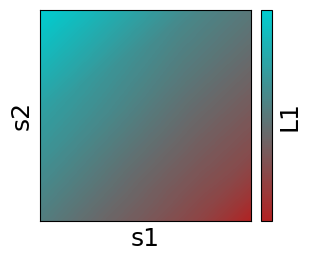

In [44]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
mycolors = ['firebrick', 'darkturquoise']
cmap = mcolors.LinearSegmentedColormap.from_list('cyan_red', mycolors, N=n_bins)

fig, ax = plt.subplots(n, m, figsize=(3*m, 3*n))
im = ax.imshow(L1.reshape(200,200), extent=[0, 1, 0, 1], origin='lower', cmap=cmap)

ax.set_xlabel('s1', fontsize=fs)
ax.set_ylabel('s2', fontsize=fs)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal', adjustable='box')

# Create divider for existing axes
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = plt.colorbar(im, cax=cax)
cbar.set_label('L1', fontsize=fs)
cbar.set_ticks([])

plt.savefig("FigS6/" + 'toymodel_latentspace_v_signals.png')